In [1]:
# @launchit.collected

In [2]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

import sys
import os
from collections import namedtuple # @launchit.collect
from pathlib import Path
import json
import datetime
import pprint 
from functools import cache
import re
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io
from sklearn.preprocessing import StandardScaler

from tqdm.notebook import tqdm

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

sys.path.append(project_root_path)
from lib.utils import *
from lib.logging import *
from lib.model_registry import *
import lib.launchit # @launchit.disable

2025-12-31 16:51:13.396654: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-31 16:51:13.434936: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-31 16:51:14.258638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Setup

In [3]:
LOG = Logging()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, data_path, sparsenet_path, metrics_path, ' + 
                    'notebook_fname, notebook_name, is_cuda, cuda_device')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    data_path=os.path.join(project_root_path, 'data'),
    sparsenet_path=os.path.join(project_root_path, 'data', 'sparsenet'),
    metrics_path=os.path.expanduser('~/tensorboard'),
    notebook_fname='noname.ipynb',
    notebook_name='noname',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu'
)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    CONFIG = CONFIG._replace(notebook_fname=notebook_fname, notebook_name=notebook_name)

print('CONFIG=\n' + pprint.pformat(CONFIG._asdict()))
print('')

# @launchit.disable
# @launchit.collect
MODEL_INSTANCE_INFO = namedtuple('ModelInstanceInfo', 'group_uri, name, version, main_asset_fname')(
    group_uri='${MODEL_GROUP_URI}',
    name='${MODEL_NAME}',
    version=0,
    main_asset_fname='${LAUNCHIT_FNAME}'
)
# @launchit.stop

MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(group_uri=f'{CONFIG.project_root_uri}.{os.path.basename(os.path.dirname(notebook_fname))}')
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(name=CONFIG.notebook_name)
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(main_asset_fname=CONFIG.notebook_fname)
# @launchit.stop

print('MODEL_INSTANCE_INFO=\n' + pprint.pformat(MODEL_INSTANCE_INFO._asdict()))

MODEL_REGISTRY = ModelRegistry(MODEL_INSTANCE_INFO.group_uri)

CONFIG=
{'cuda_device': 'cpu',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'is_cuda': False,
 'metrics_path': '/home/misha/tensorboard',
 'notebook_fname': '/home/misha/dev/mine/neurovision/denoise/s2_denoising_ae_02.ipynb',
 'notebook_name': 's2_denoising_ae_02',
 'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'sparsenet_path': '/home/misha/dev/mine/neurovision/data/sparsenet'}

MODEL_INSTANCE_INFO=
{'group_uri': 'com.develorium.neurovision.denoise',
 'main_asset_fname': '/home/misha/dev/mine/neurovision/denoise/s2_denoising_ae_02.ipynb',
 'name': 's2_denoising_ae_02',
 'version': 0}


# Launchit

In [4]:
# @launchit.disable
launchit_t0 = time.time()

In [6]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    expandvars = dict(
        MODEL_GROUP_URI=MODEL_INSTANCE_INFO.group_uri,
        MODEL_NAME=MODEL_INSTANCE_INFO.name,
    )
    lib.launchit.launchit(CONFIG.notebook_fname, expandvars)
else:
    print('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/denoise/s2_denoising_ae_02-launch5.ipynb
Cell 0, launchit stanza: "# @launchit.collected"
Cell 1, launchit stanza: "from collections import namedtuple # @launchit.collect"
Cell 1, launchit stanza: "import lib.launchit # @launchit.disable"
Cell 3, launchit stanza: "# @launchit.disable"
Cell 3, launchit stanza: "# @launchit.collect"
Cell 3, launchit stanza: "# @launchit.stop"
Cell 3, command COLLECT at line 27 will stop at line 34
Cell 3, launchit stanza: "# @launchit.stop"
Cell 3, command DISABLE at line 26 will stop at line 39
Cell 5, launchit stanza: "# @launchit.disable"
Cell 6, launchit stanza: "# @launchit.disable"
Cell 8, launchit stanza: "# @launchit.disable"
Cell 8, launchit stanza: "# @launchit.collect"
Cell 14, launchit stanza: "# @launchit.disable"
Cell 22, launchit stanza: "# @launchit.disable"
Cell 24, launchit stanza: "# @launchit.disable"
Cell 24, launchit stanza: "# @launchit.collect"
Cell 30, launchit stanza: "# @launchit.disabl

# Hypers

In [6]:
# @launchit.disable
# @launchit.collect
HP = namedtuple('HyperParameters', [
    'images_slot',
    'dataset_size',
    'dataset_preprocessing',
    'patch_size',
    'noise',
    'filters_count',
    'batch_size',
    'epochs_count',
    'learn_rate', 
], defaults=[None] * 9)(
    images_slot='RAW'
)

# Images

In [7]:
def add_images_to_lib(images, tag):
    IMAGES_LIB[tag] = dict(images=images, image_stds=images.reshape(images.shape[0], -1).std(axis=1))

In [8]:
IMAGES_LIB = {
    'RAW': dict(fname='IMAGES_RAW.mat', mat_name='IMAGESr'),
    'WHITENED': dict(fname='IMAGES.mat', mat_name='IMAGES'),
}

for k in IMAGES_LIB:
    fname = IMAGES_LIB[k]['fname']
    mat_name = IMAGES_LIB[k]['mat_name']
    mat = scipy.io.loadmat(os.path.join(CONFIG.sparsenet_path, fname))
    images = mat[mat_name]
    images = np.moveaxis(images, [2], [0])
    add_images_to_lib(images, k)

# Patching

In [9]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, patch_size, image_ind=None, image_stds=None, rng=None):
    blind_area = 4
    trials = 1000
    rng = RNG if rng is None else rng
    image_ind = rng.choice(len(images)) if image_ind is None else image_ind
    image = images[image_ind]

    with_std = not image_stds is None
    
    if with_std:
        image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + rng.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + rng.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

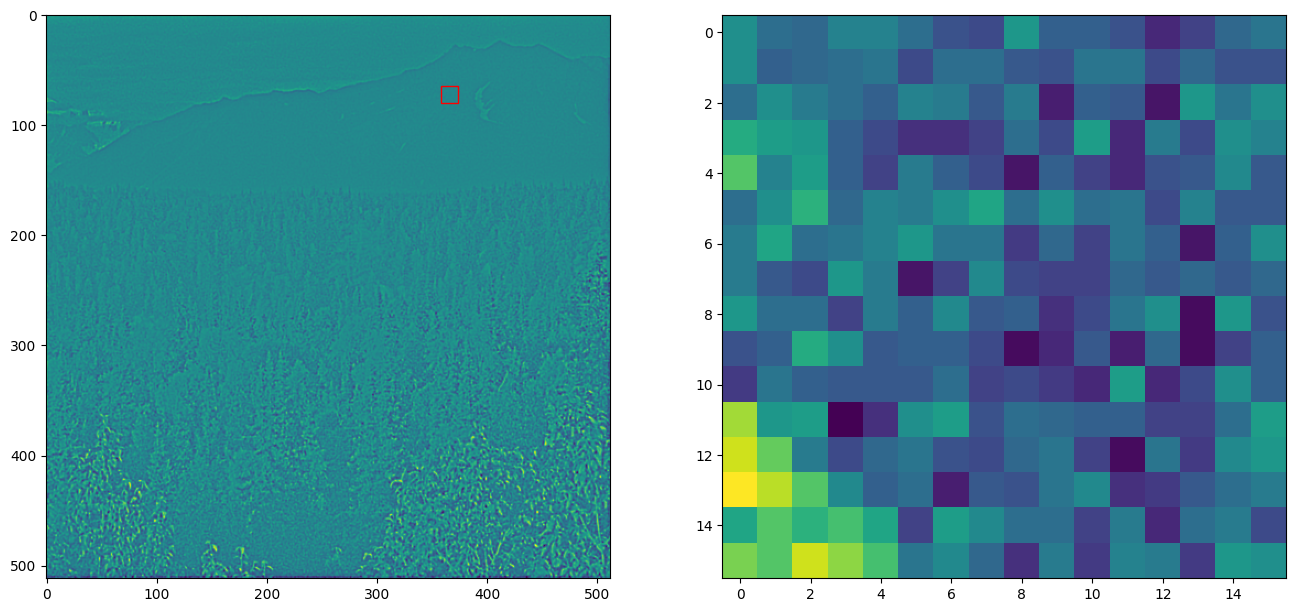

In [10]:
# @launchit.disable
slot = IMAGES_LIB[HP.images_slot]
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.imshow(images[image_ind]);
rect = pltpatches.Rectangle((j_off, i_off), patch.shape[1], patch.shape[0], linewidth=1, edgecolor='r', facecolor='none')
ax1.add_patch(rect)
ax2.imshow(patch);

# Noising

## gauss_noise

In [11]:
def gauss_noise(patches, gadds_tab):
    if patches.ndim == 2:
        assert patches.shape[1] == gadds_tab.shape[1], f'Shape mismatch: {patches.shape[1]} vs {gadds_tab.shape[1]}'
        patches_count = len(patches)
        noise = gadds_tab[RNG.choice(len(gadds_tab), patches_count)]
    elif patches.ndim == 1:
        gadd_ind = RNG.choice(len(gadds_tab))
        noise = gadds_tab[gadd_ind]
    else:
        assert False, f'Unsupported dimensions count for patches: {patches.ndim}'

    if isinstance(patches, np.ndarray):
        return patches + noise
    elif isinstance(patches, torch.Tensor):
        return patches + torch.tensor(noise, device=patches.device, dtype=patches.dtype)

## masking_noise

In [12]:
def masking_noise(patches, masks_tab, fill_value=0):
    if patches.ndim == 2:
        assert patches.shape[1] == masks_tab.shape[1], f'Shape mismatch: {patches.shape[1]} vs {masks_tab.shape[1]}'
        patches_count = len(patches)
        mask_inds = RNG.choice(len(masks_tab), patches_count, replace=False)
        boolmap = masks_tab[mask_inds]
    elif patches.ndim == 1:
        mask_ind = RNG.choice(len(masks_tab))
        boolmap = masks_tab[mask_ind]
    else:
        assert False, f'Unsupported dimensions count for patches: {patches.ndim}'

    if isinstance(patches, np.ndarray):
        noised = patches.copy()
    elif isinstance(patches, torch.Tensor):
        noised = patches.clone()
    else:
        assert False, f'Unsupported type(patches): {type(patches)}'

    noised[boolmap] = fill_value
    return noised

## generate_zmasks

In [13]:
def generate_zmasks(patch_size, ν, count):
    patch_flat_size = patch_size ** 2
    zero_inds_count = int(ν * patch_flat_size)
    zmasks = np.full((count, patch_flat_size), False)
    
    for i in range(count):
        zero_inds = RNG.choice(patch_flat_size, zero_inds_count, replace=False)
        zmasks[i,zero_inds] = True

    return zmasks    

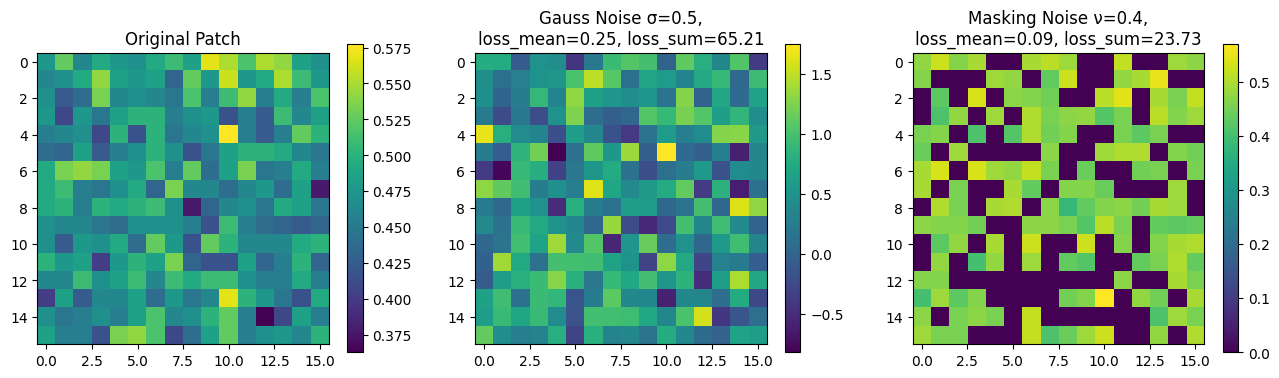

In [14]:
# @launchit.disable
slot = IMAGES_LIB[HP.images_slot]
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original Patch')
im = ax1.imshow(patch);
fig.colorbar(im, ax=ax1, shrink=.5)

σ = 0.5
gadds = RNG.normal(0, σ, (100, patch.shape[0]**2))
noised = gauss_noise(patch.ravel(), gadds)
noised = noised.reshape(patch.shape)
ax2.set_title(f'Gauss Noise σ={σ},\nloss_mean={((patch - noised)**2).mean():.2f}, loss_sum={((patch - noised)**2).sum():.2f}')
im = ax2.imshow(noised);
fig.colorbar(im, ax=ax2, shrink=.5)

ν = 0.4
zmasks = generate_zmasks(patch.shape[1], ν, 100)
noised = masking_noise(patch.ravel(), zmasks, fill_value=0)
noised = noised.reshape(patch.shape)
ax3.set_title(f'Masking Noise ν={ν},\nloss_mean={((patch - noised)**2).mean():.2f}, loss_sum={((patch - noised)**2).sum():.2f}')
im = ax3.imshow(noised);
fig.colorbar(im, ax=ax3, shrink=.5);

# Dataset

In [15]:
# @launchit.disable
# @launchit.collect
HP = HP._replace(
    dataset_size=1_000_000,
    dataset_preprocessing='ZCA_HFR30_WHITEN', # NONE, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
    patch_size=12,
)

## Populate

In [16]:
@cache
def generate_dataset(dataset_size, patch_size, images_slot):
    dataset_rng = np.random.default_rng(82)
    images = IMAGES_LIB[images_slot]['images']
    dataset = []
    
    for i in tqdm(range(dataset_size)):
        patch = extract_image_patch(images, patch_size, rng=dataset_rng).patch
        dataset.append(patch.ravel())
    
    return np.array(dataset)

In [17]:
fname = os.path.join(CONFIG.data_path, 'denoise', f'dataset-{HP.images_slot.lower()}.pkl')

if os.path.exists(fname):
    with open(fname, 'rb') as f:
        DATASET = pickle.load(f)
        
    print(f'Dataset loaded from "{fname}"')
else:
    DATASET = generate_dataset(HP.dataset_size, HP.patch_size, HP.images_slot)

    os.makedirs(os.path.dirname(fname), exist_ok=True)

    with open(fname, 'wb') as f:
        pickle.dump(DATASET, f)

    print(f'Dataset saved to "{fname}"')

  0%|          | 0/1000000 [00:00<?, ?it/s]

Dataset saved to "/home/misha/dev/mine/neurovision/data/denoise/dataset-raw.pkl"


## Preprocess

In [18]:
match HP.dataset_preprocessing:
    case 'STANDARDIZE':
        DATASET_SCALER = StandardScaler()
        DATASET = DATASET_SCALER.fit_transform(DATASET)
    case 'ZCA_WHITEN':
        DATASET_SCALER = StandardScaler(with_std=False)
        DATASET = DATASET_SCALER.fit_transform(DATASET)
        
        Σ = np.cov(DATASET, rowvar=False)
        u, s, _ = np.linalg.svd(Σ)
        DATASET = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ DATASET.T).T
    case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
        DATASET_SCALER = StandardScaler(with_std=False)
        DATASET = DATASET_SCALER.fit_transform(DATASET)

        Σ = np.cov(DATASET, rowvar=False)
        eigvals, eigvecs = np.linalg.eig(Σ)
        eigvals_order = np.argsort(-eigvals)
        wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
        eigvals_w = eigvals.copy()
        eigvals_w[wipeout_inds] = 0
        
        R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
        S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
        R_inv = R.T
        W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
        DATASET = (W @ DATASET.T).T
    case 'NONE':
        pass
    case _:
        assert False, f'Unsupported dataset_preprocessing={HP.dataset_preprocessing}'
    
DATASET = torch.Tensor(DATASET)
DATASET = DATASET.contiguous() # force dense memory layout (speeds up DataLoader x2)

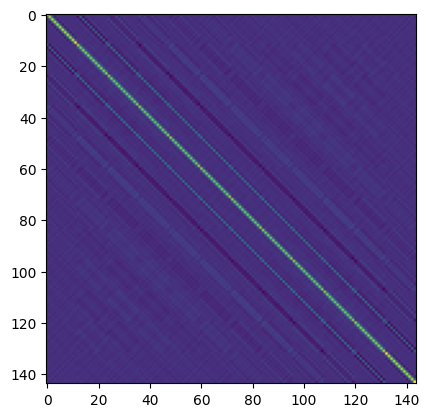

In [19]:
# @launchit.disable
plt.imshow(np.cov(DATASET, rowvar=False));

# Model

In [20]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, hiddens_count, noise_func):
        super().__init__()
        self.filters = tnn.Linear(inp_dims_count, hiddens_count)
        self.decoder = tnn.Linear(hiddens_count, inp_dims_count)
        self.noise_func = noise_func

        bound = 1 / np.sqrt(inp_dims_count)
        self.filters.weight.data.uniform_(-bound, bound)
        bound = 1 / np.sqrt(hiddens_count)
        self.decoder.weight.data.uniform_(-bound, bound)

    def forward(self, inp):
        noised = self.noise_func(inp)
        out = tnnf.sigmoid(self.filters(noised))
        out = self.decoder(out)
        
        if self.training:
            return out
        else:
            return out, noised

In [21]:
model = DenoiseAutoencoder(144, 200, lambda p: gauss_noise(p, RNG.normal(0, 0.5, (100, 144))))
sum([p.numel() for p in model.parameters()])

57944

In [22]:
data_loader = DataLoader(DATASET, batch_size=100)
model(next(iter(data_loader))).shape

torch.Size([100, 144])

# Training

We trained both regular autoencoders and denoising autoencoders on 12×12 patches from whitened natural scene images, made available by Olshausen (Olshausen and Field, 1996)... 

For these natural image patches, we used a linear decoder and a squared reconstruction cost. Network parameters were trained from a random start, using stochastic gradient descent to perform 500000 weight updates with a fixed learning rate of 0.05. All filters shown were from experiments with tied weights, but untied weights yielded similar results.

We then trained 200 hidden units over-complete noiseless autoencoders regularized with L2 weight decay, as well as 200 hidden units denoising autoencoders with isotropic Gaussian noise (but no weight decay). ... With a sufficiently large noise level however (σ = 0.5), the denoising autoencoder learns Gabor-like local oriented edge detectors 

In [23]:
@cache
def gadds(σ):
    return RNG.normal(0, σ, (HP.dataset_size, HP.patch_size**2)).astype(float)

@cache
def zmasks(ν):
    return generate_zmasks(HP.patch_size, ν, HP.dataset_size)

In [24]:
noise_funcs = {
    'Gauss_0.5': lambda p: gauss_noise(p, gadds(0.5)),
    'Masking_0.1': lambda p: masking_noise(p, zmasks(0.1)),
    'Masking_0.25': lambda p: masking_noise(p, zmasks(0.25)),
    'Masking_0.25_1': lambda p: masking_noise(p, zmasks(0.25), fill_value=1),
    'Masking_0.4': lambda p: masking_noise(p, zmasks(0.4)),
    'Masking_0.55': lambda p: masking_noise(p, zmasks(0.55)),
}
# @launchit.disable
# @launchit.collect
HP = HP._replace(
    filters_count=200,
    batch_size=10_000,
    epochs_count=500,
    learn_rate=0.01,
    noise='Masking_0.55',
)
# @launchit.stop
pprint.pprint(HP._asdict())

{'batch_size': 10000,
 'dataset_preprocessing': 'ZCA_HFR30_WHITEN',
 'dataset_size': 1000000,
 'epochs_count': 500,
 'filters_count': 200,
 'images_slot': 'RAW',
 'learn_rate': 0.01,
 'noise': 'Masking_0.55',
 'patch_size': 12}


In [38]:
data_loader = DataLoader(DATASET, batch_size=HP.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
model = DenoiseAutoencoder(HP.patch_size**2, HP.filters_count, noise_funcs[HP.noise]).to(device=CONFIG.cuda_device)
optimizer = topt.Adam(model.parameters(), lr=HP.learn_rate)
loss_fn = tnn.MSELoss()
epoch = 0

# MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=18)

if MODEL_INSTANCE_INFO.version == 0:
    new_model_instance_version = MODEL_REGISTRY.register_model(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.main_asset_fname)
    MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=new_model_instance_version)
    print(f'Model instance registered, version={MODEL_INSTANCE_INFO.version}')
else:
    pt_data = MODEL_REGISTRY.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'pt')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = int(checkpoint['epoch'])
    print(f'Model instance loaded from version={MODEL_INSTANCE_INFO.version}, epoch={epoch}')

metrics_dir = os.path.join(CONFIG.metrics_path, MODEL_INSTANCE_INFO.name, f'{MODEL_INSTANCE_INFO.version}:{datetime.datetime.now().strftime('%y%m%d:%H%M%S')}')
metrics_writer = SummaryWriter(log_dir=metrics_dir)
metrics_writer.add_text('hypers', pprint.pformat(HP._asdict()), 1)
metrics_writer.add_text('config', pprint.pformat(CONFIG._asdict()), 1)
print(f'metrics_dir={metrics_dir}')

Model instance loaded from version=18, epoch=500


AssertionError: 

In [ ]:
model.train()

for epoch in tqdm(range(epoch + 1, epoch + HP.epochs_count + 1)):
    loss_train = 0
    
    for batch in data_loader:
        optimizer.zero_grad()
        
        true_data = batch.to(device=CONFIG.cuda_device)
        infer_data = model(true_data)
        loss = loss_fn(infer_data, true_data)
        loss.backward()
        
        optimizer.step()
        
        loss_train += loss.item()
    
    metrics_writer.add_scalar('loss', loss_train / len(data_loader), epoch)

    if (epoch % 20) == 0:
        bases_in_row = 10
        fig, axes = plt.subplots(int(np.ceil(HP.filters_count / bases_in_row)), bases_in_row)
        fig.set_figwidth(12)
        fig.set_figheight(18)
        filters = model.filters.weight.to(device='cpu').detach()
        
        for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
            ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
            ax.imshow(vec_to_square_matrix(f), cmap='gray')
            ax.set_xticks([])
            ax.set_yticks([])
        
        fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Epoch {epoch},\n{pprint.pformat(HP._asdict())}\n')
        plt.tight_layout()
        
        metrics_writer.add_figure('filters', fig, epoch, close=True)
    
    metrics_writer.flush()

In [ ]:
meta = dict(epoch=epoch, hypers=HP._asdict(), config=CONFIG._asdict())

with io.StringIO() as b:
    json.dump(meta, b)
    MODEL_REGISTRY.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'meta', replace=True)

with io.BytesIO() as b:
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    MODEL_REGISTRY.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'pt', replace=True)

In [ ]:
# @launchit.disable
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

ind = RNG.choice(len(DATASET))
clean = DATASET[ind]

model.eval()

with torch.no_grad():
    reconstructed, noised = model(clean.reshape(1, -1).to(CONFIG.cuda_device))
    reconstructed = reconstructed.to(device='cpu').detach().ravel()
    noised = noised.to(device='cpu').detach().ravel()

ax1.set_title('Clean')
ax1.imshow(vec_to_square_matrix(clean))

ax2.set_title(f'Noised, loss={loss_fn(noised, clean):.3f}')
ax2.imshow(vec_to_square_matrix(noised))

ax3.set_title(f'Reconstructed, loss={loss_fn(reconstructed, clean):.3f}')
ax3.imshow(vec_to_square_matrix(reconstructed));

plt.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Patch #{ind}')

metrics_writer.add_figure('example', fig, epoch, close=False)
metrics_writer.flush()

In [ ]:
# @launchit.disable
bases_in_row = 10
fig, axes = plt.subplots(int(np.ceil(HP.filters_count / bases_in_row)), bases_in_row)#, dpi=150)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = model.filters.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(vec_to_square_matrix(f), cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Epoch {epoch},\n{pprint.pformat(HP._asdict())}\n')
plt.tight_layout()

metrics_writer.add_figure('filters', fig, epoch, close=False)
metrics_writer.flush()